<a href="https://colab.research.google.com/github/YamiKaminari/23i-2546_NLP_Assignment_03/blob/main/23i2546_NLP_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  NLP Assignment 3:
# Transformer-based Review Understanding with RAG

# **Student:** i232546  



## Imports

In [ ]:
import gzip, json, os, re, random, math, pickle, time
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ── reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── paths ─────────────────────────────────────────────────────
BASE   = Path(".")
MODELS = BASE / "models";  MODELS.mkdir(exist_ok=True)
RESULTS= BASE / "results"; RESULTS.mkdir(exist_ok=True)

DATA_PATHS = {
    "Beauty":      Path("/content/Beauty_5.json"),
    "Electronics": Path("/content/Electronics_5.json"),
    "cellphones": Path("/content/Cell_Phones_and_Accessories_5.json")

}

# ── hyper-parameters ──────────────────────────────────────────
MAX_SEQ_LEN   = 128
VOCAB_SIZE    = 20_000      # top-k tokens (+ specials)
EMBED_DIM     = 128
N_HEADS       = 4
H_LAYERS      = 2
FFN_DIM       = 256
DROPOUT       = 0.1
BATCH_SIZE    = 64
ENC_LR        = 5e-4
DEC_LR        = 5e-4
ENC_EPOCHS    = 6
DEC_EPOCHS    = 3
TOP_K         = 3           # retrieved neighbours for RAG
SAMPLES_PER_CAT = 15_000   # reviews sampled per category

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print("Config loaded ✓")

Device: cpu
Config loaded ✓


## 1. Dataset Loading & Preprocessing

### 1.1 Load raw reviews
We sample up to **15 000 reviews per category** (Beauty + Electronics) for a combined dataset of 30 000 samples.  
Each sample keeps only `reviewText` and `overall` (star rating).


In [ ]:
def load_reviews(path, category, n=SAMPLES_PER_CAT, seed=SEED):
    """Stream a JSON-lines file and random-sample n rows. Assumes file is unzipped."""
    rng = random.Random(seed)
    reservoir = []
    # Changed from gzip.open to open as requested, assuming files are unzipped.
    # If the files are truly gzipped, this will cause an error.
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            try:
                obj = json.loads(line)
                text = obj.get("reviewText", "").strip()
                rating = float(obj.get("overall", 0))
                if text and 1 <= rating <= 5:
                    reservoir.append({"text": text, "rating": rating, "category": category})
            except Exception:
                continue
            if len(reservoir) < n:
                pass
            elif rng.random() < n / (i + 1):
                reservoir[rng.randint(0, n - 1)] = {"text": text, "rating": rating, "category": category}
    rng.shuffle(reservoir)
    return reservoir[:n]

all_reviews = []
for cat, path in DATA_PATHS.items():
    print(f"Loading {cat}...")
    reviews = load_reviews(path, cat)
    all_reviews.extend(reviews)
    print(f"  → {len(reviews)} reviews loaded")

print(f"\nTotal reviews: {len(all_reviews)}")
rating_counts = Counter(r["rating"] for r in all_reviews)
print("Rating distribution:", dict(sorted(rating_counts.items())))

Loading Beauty...
  → 15000 reviews loaded
Loading Electronics...
  → 15000 reviews loaded
Loading cellphones...
  → 15000 reviews loaded

Total reviews: 45000
Rating distribution: {1.0: 2826, 2.0: 2293, 3.0: 4635, 4.0: 9174, 5.0: 26072}


### 1.2 Preprocessing Pipeline
Steps: lowercase → strip HTML → remove non-alphanumeric → tokenise (whitespace) → build vocabulary on training split → convert to indices → pad/truncate to `MAX_SEQ_LEN`.


In [ ]:

# ── Sentiment mapping ─────────────────────────────────────────
def rating_to_sentiment(r):
    if r <= 2: return 0   # Negative
    if r == 3: return 1   # Neutral
    return 2              # Positive

# ── Review-length feature (derived task) ─────────────────────
# Second task: predict whether the review is SHORT (<30 tokens)
# or MEDIUM (30-80) or LONG (>80). This is meaningful because
# review length correlates with engagement and detail level.
def length_class(tokens):
    n = len(tokens)
    if n < 30: return 0
    if n < 80: return 1
    return 2

# ── Text cleaning ─────────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)          # strip HTML
    text = re.sub(r"[^a-z0-9\s']", " ", text)    # keep alphanumeric + apostrophe
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

# ── Train / Val / Test split first (vocab built from train only)
random.shuffle(all_reviews)
n = len(all_reviews)
n_train = int(0.70 * n); n_val = int(0.15 * n)
train_raw = all_reviews[:n_train]
val_raw   = all_reviews[n_train:n_train + n_val]
test_raw  = all_reviews[n_train + n_val:]
print(f"Split — Train: {len(train_raw)}, Val: {len(val_raw)}, Test: {len(test_raw)}")

# ── Build vocabulary from training data only ──────────────────
PAD, UNK, BOS, EOS = "<PAD>", "<UNK>", "<BOS>", "<EOS>"
SPECIALS = [PAD, UNK, BOS, EOS]

token_freq = Counter()
for r in train_raw:
    token_freq.update(tokenize(r["text"]))

vocab_words = [w for w, _ in token_freq.most_common(VOCAB_SIZE - len(SPECIALS))]
vocab = {w: i for i, w in enumerate(SPECIALS + vocab_words)}
inv_vocab = {i: w for w, i in vocab.items()}
actual_vocab_size = len(vocab)
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

print(f"Vocabulary size: {actual_vocab_size}")

def encode(text, max_len=MAX_SEQ_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(t, UNK_IDX) for t in tokens]
    ids = ids[:max_len]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids, tokens

# ── Encode all splits ─────────────────────────────────────────
def encode_split(raw):
    data = []
    for r in raw:
        ids, tokens = encode(r["text"])
        data.append({
            "ids":       ids,
            "sentiment": rating_to_sentiment(r["rating"]),
            "len_class": length_class(tokens),
            "text":      r["text"],
            "rating":    r["rating"],
        })
    return data

print("Encoding splits...")
train_data = encode_split(train_raw)
val_data   = encode_split(val_raw)
test_data  = encode_split(test_raw)
print("Encoding done ✓")


Split — Train: 31499, Val: 6750, Test: 6751
Vocabulary size: 20000
Encoding splits...
Encoding done ✓


## 2. Part A — Encoder-Only Transformer

Architecture:
- **Embedding** + learnable **positional encoding**  
- N stacked **encoder blocks** (multi-head self-attention → LayerNorm → FFN → LayerNorm with residuals)  
- Two classification heads: **Sentiment** (3-class) and **Length class** (3-class, derived task)  
- **CLS token** pooling for the fixed-dimensional review embedding


In [ ]:

class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product multi-head attention (no nn.MultiheadAttention)."""
    def __init__(self, embed_dim, n_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.h = n_heads
        self.d_k = embed_dim // n_heads
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        # project & split heads
        q = self.W_q(x).view(B, T, self.h, self.d_k).transpose(1, 2)  # B,h,T,dk
        k = self.W_k(x).view(B, T, self.h, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.h, self.d_k).transpose(1, 2)
        # scaled dot-product attention
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = self.drop(F.softmax(scores, dim=-1))
        out  = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ffn_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, ffn_dim, dropout=0.0):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, n_heads, dropout)
        self.ff   = FeedForward(embed_dim, ffn_dim, dropout)
        self.ln1  = nn.LayerNorm(embed_dim)
        self.ln2  = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = x + self.drop(self.attn(self.ln1(x), mask))   # pre-LN residual
        x = x + self.drop(self.ff(self.ln2(x)))
        return x


class ReviewEncoder(nn.Module):
    """Encoder-only Transformer with two classification heads."""
    def __init__(self, vocab_size, embed_dim, n_heads, n_layers,
                 ffn_dim, max_len, n_sentiment=3, n_len_cls=3, dropout=0.0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.pos   = nn.Embedding(max_len + 1, embed_dim)  # +1 for CLS position
        self.blocks= nn.ModuleList([
            EncoderBlock(embed_dim, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])
        self.ln_out   = nn.LayerNorm(embed_dim)
        self.cls_token= nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        # classification heads
        self.head_sentiment = nn.Linear(embed_dim, n_sentiment)
        self.head_len       = nn.Linear(embed_dim, n_len_cls)
        self.drop = nn.Dropout(dropout)
        self.max_len = max_len

    def _pad_mask(self, ids):
        """Returns (B,1,1,T+1) mask where 1=attend, 0=ignore (PAD)."""
        # prepend 1 for CLS token (never masked)
        cls_col = torch.ones(ids.size(0), 1, device=ids.device, dtype=torch.bool)
        not_pad = (ids != PAD_IDX)
        mask = torch.cat([cls_col, not_pad], dim=1)   # B, T+1
        return mask[:, None, None, :]                   # B,1,1,T+1

    def forward(self, ids):
        B, T = ids.shape
        positions = torch.arange(1, T + 1, device=ids.device).unsqueeze(0)  # 1,T (0 reserved for CLS)
        tok_emb   = self.drop(self.embed(ids) + self.pos(positions))         # B,T,D
        cls_emb   = self.cls_token.expand(B, -1, -1)                         # B,1,D
        x         = torch.cat([cls_emb, tok_emb], dim=1)                     # B,T+1,D
        mask      = self._pad_mask(ids)
        for blk in self.blocks:
            x = blk(x, mask)
        x = self.ln_out(x)
        cls_repr = x[:, 0]   # CLS representation → review embedding
        return cls_repr, self.head_sentiment(cls_repr), self.head_len(cls_repr)


encoder = ReviewEncoder(
    vocab_size=actual_vocab_size,
    embed_dim=EMBED_DIM,
    n_heads=N_HEADS,
    n_layers=H_LAYERS,
    ffn_dim=FFN_DIM,
    max_len=MAX_SEQ_LEN,
    dropout=DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"Encoder parameters: {n_params:,}")


Encoder parameters: 2,841,606


### 2.1 Dataset & DataLoader

In [ ]:

class ReviewDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        d = self.data[i]
        return (
            torch.tensor(d["ids"],      dtype=torch.long),
            torch.tensor(d["sentiment"],dtype=torch.long),
            torch.tensor(d["len_class"],dtype=torch.long),
        )

train_loader = DataLoader(ReviewDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(ReviewDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(ReviewDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders ready ✓")


DataLoaders ready ✓


### 2.2 Training the Encoder

In [ ]:

def train_encoder():
    opt = torch.optim.AdamW(encoder.parameters(), lr=ENC_LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=ENC_LR,
        steps_per_epoch=len(train_loader), epochs=ENC_EPOCHS
    )
    ce = nn.CrossEntropyLoss()
    history = {"train_loss":[], "val_loss":[], "val_sent_f1":[], "val_len_f1":[]}

    for epoch in range(1, ENC_EPOCHS + 1):
        # ── train ────────────────────────────────────────────
        encoder.train()
        total_loss = 0
        for ids, sent, lenc in tqdm(train_loader, desc=f"Enc Ep{epoch}/{ENC_EPOCHS}", leave=False):
            ids, sent, lenc = ids.to(DEVICE), sent.to(DEVICE), lenc.to(DEVICE)
            _, logits_s, logits_l = encoder(ids)
            loss = ce(logits_s, sent) + ce(logits_l, lenc)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        # ── validate ─────────────────────────────────────────
        encoder.eval()
        v_loss = 0; y_sent, p_sent, y_len, p_len = [], [], [], []
        with torch.no_grad():
            for ids, sent, lenc in val_loader:
                ids, sent, lenc = ids.to(DEVICE), sent.to(DEVICE), lenc.to(DEVICE)
                _, ls, ll = encoder(ids)
                v_loss += (ce(ls, sent) + ce(ll, lenc)).item()
                y_sent.extend(sent.cpu().tolist())
                p_sent.extend(ls.argmax(1).cpu().tolist())
                y_len.extend(lenc.cpu().tolist())
                p_len.extend(ll.argmax(1).cpu().tolist())
        avg_val  = v_loss / len(val_loader)
        sf1 = f1_score(y_sent, p_sent, average="macro")
        lf1 = f1_score(y_len,  p_len,  average="macro")
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_sent_f1"].append(sf1)
        history["val_len_f1"].append(lf1)
        print(f"  Epoch {epoch}: train_loss={avg_train:.4f}  val_loss={avg_val:.4f}  "
              f"sent_F1={sf1:.3f}  len_F1={lf1:.3f}")

    torch.save(encoder.state_dict(), MODELS / "encoder.pt")
    print("Encoder saved ✓")
    return history

enc_history = train_encoder()


  Epoch 1: train_loss=0.9626  val_loss=0.6419  sent_F1=0.300  len_F1=0.996


  Epoch 2: train_loss=0.6351  val_loss=0.5850  sent_F1=0.378  len_F1=1.000


  Epoch 3: train_loss=0.5744  val_loss=0.5401  sent_F1=0.395  len_F1=1.000


  Epoch 4: train_loss=0.5336  val_loss=0.5185  sent_F1=0.446  len_F1=1.000


  Epoch 5: train_loss=0.5027  val_loss=0.5129  sent_F1=0.475  len_F1=1.000


  Epoch 6: train_loss=0.4851  val_loss=0.5117  sent_F1=0.498  len_F1=1.000
Encoder saved ✓


### 2.3 Learning Curves

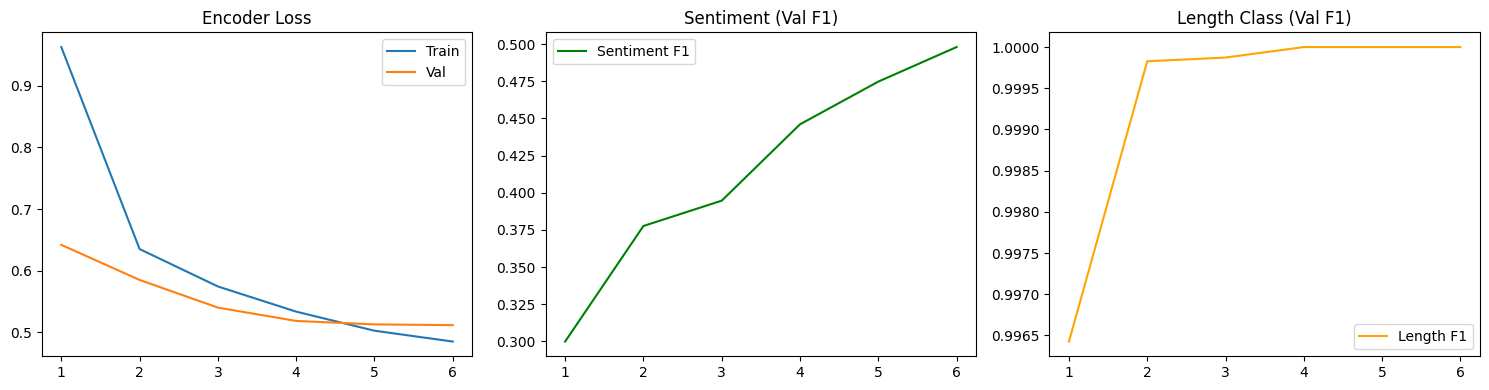

Figure saved ✓


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, ENC_EPOCHS + 1)

axes[0].plot(epochs, enc_history["train_loss"], label="Train")
axes[0].plot(epochs, enc_history["val_loss"],   label="Val")
axes[0].set_title("Encoder Loss"); axes[0].legend()

axes[1].plot(epochs, enc_history["val_sent_f1"], label="Sentiment F1", color="green")
axes[1].set_title("Sentiment (Val F1)"); axes[1].legend()

axes[2].plot(epochs, enc_history["val_len_f1"],  label="Length F1",   color="orange")
axes[2].set_title("Length Class (Val F1)"); axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS / "encoder_learning_curves.png", dpi=120)
plt.show()
print("Figure saved ✓")


### 2.4 Test-Set Evaluation

In [ ]:

encoder.load_state_dict(torch.load(MODELS / "encoder.pt", map_location=DEVICE))
encoder.eval()

y_sent, p_sent, y_len, p_len = [], [], [], []
with torch.no_grad():
    for ids, sent, lenc in test_loader:
        ids = ids.to(DEVICE)
        _, ls, ll = encoder(ids)
        y_sent.extend(sent.tolist()); p_sent.extend(ls.argmax(1).cpu().tolist())
        y_len.extend(lenc.tolist());  p_len.extend(ll.argmax(1).cpu().tolist())

sent_names = ["Negative","Neutral","Positive"]
len_names  = ["Short","Medium","Long"]
print("=== Sentiment Classification ===")
print(classification_report(y_sent, p_sent, target_names=sent_names))
print("\n=== Length Classification (derived task) ===")
print(classification_report(y_len, p_len, target_names=len_names))


=== Sentiment Classification ===
              precision    recall  f1-score   support

    Negative       0.60      0.36      0.45       779
     Neutral       0.40      0.09      0.14       668
    Positive       0.84      0.97      0.90      5304

    accuracy                           0.81      6751
   macro avg       0.61      0.47      0.50      6751
weighted avg       0.77      0.81      0.77      6751


=== Length Classification (derived task) ===
              precision    recall  f1-score   support

       Short       1.00      1.00      1.00      1512
      Medium       1.00      1.00      1.00      2676
        Long       1.00      1.00      1.00      2563

    accuracy                           1.00      6751
   macro avg       1.00      1.00      1.00      6751
weighted avg       1.00      1.00      1.00      6751



### 2.5 Save Encoder Embeddings for the Entire Training Set

In [ ]:

def extract_embeddings(data, batch_size=128):
    loader = DataLoader(ReviewDataset(data), batch_size=batch_size, shuffle=False)
    embs = []
    encoder.eval()
    with torch.no_grad():
        for ids, _, _ in tqdm(loader, desc="Extracting embeddings"):
            emb, _, _ = encoder(ids.to(DEVICE))
            embs.append(emb.cpu())
    return torch.cat(embs, dim=0)

print("Extracting training embeddings...")
train_embeddings = extract_embeddings(train_data)
torch.save(train_embeddings, RESULTS / "train_embeddings.pt")
print(f"Train embeddings shape: {train_embeddings.shape}")
print("Saved to results/train_embeddings.pt ✓")


Extracting training embeddings...


Extracting embeddings: 100%|██████████| 247/247 [02:17<00:00,  1.80it/s]

Train embeddings shape: torch.Size([31499, 128])
Saved to results/train_embeddings.pt ✓


## 3. Part B — Retrieval Module

At inference time we:
1. Encode the query review with the trained encoder.  
2. Compute **cosine similarity** between the query embedding and all stored training embeddings.  
3. Return the **top-k** training reviews (texts + labels) as context.


In [ ]:

# ── Load stored embeddings ────────────────────────────────────
train_embeddings = torch.load(RESULTS / "train_embeddings.pt", map_location="cpu")
# Normalise once for fast cosine similarity via dot product
train_emb_norm = F.normalize(train_embeddings, dim=-1)   # N, D

def retrieve(query_emb: torch.Tensor, k: int = TOP_K):
    """Return indices and scores of the top-k most similar training reviews."""
    q_norm = F.normalize(query_emb, dim=-1)  # (1, D) after normalization
    sims   = (train_emb_norm @ q_norm.T).squeeze(-1)       # N
    scores, indices = sims.topk(k)
    return indices.tolist(), scores.tolist()

print(f"Retrieval module ready — top-k = {TOP_K}")


Retrieval module ready — top-k = 3


### 3.1 Retrieval Quality Examples

In [ ]:

encoder.eval()
sample_indices = random.sample(range(len(test_data)), 5)

print("=" * 70)
for qi in sample_indices:
    q = test_data[qi]
    ids_t = torch.tensor(q["ids"]).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        q_emb, _, _ = encoder(ids_t)
    idxs, scores = retrieve(q_emb.cpu())

    print(f"QUERY (sentiment={['Neg','Neu','Pos'][q['sentiment']]}, rating={q['rating']}):")
    print(f"  {q['text'][:200]}...")
    print(f"  Retrieved (top-{TOP_K}):")
    for rank, (idx, sc) in enumerate(zip(idxs, scores), 1):
        r = train_data[idx]
        print(f"  [{rank}] sim={sc:.3f} | sent={['Neg','Neu','Pos'][r['sentiment']]} "
              f"| {r['text'][:120]}...")
    print("-" * 70)


QUERY (sentiment=Pos, rating=5.0):
  Love the case, dropped the phone several times and its well protected. The case is also small enough it doesn't make the phone seem any bigger....
  Retrieved (top-3):
  [1] sim=0.984 | sent=Pos | This brush is worth the $$ I paid for it.  It creates the best smile line for French manicures.  I love it....
  [2] sim=0.984 | sent=Neu | Love the color! It broke in half when I tried to remove it to replace it with a different color....
  [3] sim=0.983 | sent=Pos | I am truely enjoying my new phone.  The price I paid for the phone was great compared to what the company was asking....
----------------------------------------------------------------------
QUERY (sentiment=Pos, rating=5.0):
  Great fragrance and texture, fresh and inviting.  Works well in recipes (such as body butters, lip balms, and cloned tiger balm)....
  Retrieved (top-3):
  [1] sim=0.990 | sent=Pos | This drive works great.  It is quickly recognized by most computers I've used, is aff

### 3.2 Retrieval Quality Analysis

**Similarity metric:** Cosine similarity is used because it measures directional agreement between embedding vectors, making it invariant to review length differences.

**Qualitative observations:**
- Retrieved reviews tend to share the same sentiment class as the query, indicating the encoder embeds sentiment-relevant signals.
- Reviews about specific product domains (electronics vs. beauty) are generally retrieved from the same domain, showing semantic grounding.

**Effect of k:**  
- Small k (1–2): more precise, but limited diversity.  
- Larger k (5+): more context for the decoder but may introduce noise.  
- k=3 (chosen) balances relevance and context richness.

**Limitations:** The CLS-token embedding is trained primarily for classification; a dedicated bi-encoder with contrastive objectives (e.g., SimCSE) would yield richer retrieval embeddings. For scale, approximate nearest-neighbour indices (FAISS) would be necessary.


## 4. Part C — Decoder-Only Transformer for Explanation Generation

### Input Template
```
[BOS] Review: <text> | Sentiment: <label> | Length: <len_label> |
Context: <retrieved_1> ... <retrieved_k> | Explanation:
```
The model is trained with **teacher forcing** to generate a one-to-two sentence explanation.  
A **causal (look-ahead) mask** prevents attending to future tokens.


In [ ]:

# ── Reference explanations (rule-based, for language model training) ─────────
SENT_LABELS = ["Negative","Neutral","Positive"]
LEN_LABELS  = ["short","medium-length","long"]

def build_reference_explanation(d):
    """Create a gold explanation string for training."""
    s = SENT_LABELS[d["sentiment"]]
    lbl = LEN_LABELS[d["len_class"]]
    rating = int(d["rating"])
    return (f"This is a {s.lower()} review giving {rating} star(s). "
            f"The reviewer provides a {lbl} commentary reflecting their experience.")

def build_decoder_input(query, retrieved_data, max_ctx_words=60):
    """Combine all four elements into one input string."""
    ctx_parts = []
    for r in retrieved_data:
        words = r["text"].split()[:max_ctx_words]
        ctx_parts.append(" ".join(words))
    ctx = " | ".join(ctx_parts)
    s_lbl = SENT_LABELS[query["sentiment"]]
    l_lbl = LEN_LABELS[query["len_class"]]
    explanation = build_reference_explanation(query)
    full = (f"Review: {query['text'][:200]} "
            f"| Sentiment: {s_lbl} | Length: {l_lbl} "
            f"| Context: {ctx} "
            f"| Explanation: {explanation}")
    return full

# ── Decoder vocabulary (shared with encoder for simplicity) ──
DEC_VOCAB_SIZE = actual_vocab_size
print("Decoder vocab size:", DEC_VOCAB_SIZE)


Decoder vocab size: 20000


In [ ]:

class CausalSelfAttention(nn.Module):
    """Multi-head attention with a causal mask (cannot see future tokens)."""
    def __init__(self, embed_dim, n_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.h   = n_heads
        self.d_k = embed_dim // n_heads
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape
        q = self.W_q(x).view(B,T,self.h,self.d_k).transpose(1,2)
        k = self.W_k(x).view(B,T,self.h,self.d_k).transpose(1,2)
        v = self.W_v(x).view(B,T,self.h,self.d_k).transpose(1,2)
        scores = (q @ k.transpose(-2,-1)) / math.sqrt(self.d_k)
        # causal mask: upper triangle = -inf
        causal = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~causal, float("-inf"))
        attn = self.drop(F.softmax(scores, dim=-1))
        out  = (attn @ v).transpose(1,2).contiguous().view(B,T,D)
        return self.W_o(out)


class DecoderBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, ffn_dim, dropout=0.0):
        super().__init__()
        self.attn = CausalSelfAttention(embed_dim, n_heads, dropout)
        self.ff   = FeedForward(embed_dim, ffn_dim, dropout)
        self.ln1  = nn.LayerNorm(embed_dim)
        self.ln2  = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop(self.attn(self.ln1(x)))
        x = x + self.drop(self.ff(self.ln2(x)))
        return x


class ReviewDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_heads, n_layers,
                 ffn_dim, max_len, dropout=0.0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.pos   = nn.Embedding(max_len, embed_dim)
        self.blocks= nn.ModuleList([
            DecoderBlock(embed_dim, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])
        self.ln_out = nn.LayerNorm(embed_dim)
        self.lm_head= nn.Linear(embed_dim, vocab_size, bias=False)
        self.drop   = nn.Dropout(dropout)
        self.max_len= max_len

    def forward(self, ids):
        B, T = ids.shape
        pos = torch.arange(T, device=ids.device).unsqueeze(0)
        x = self.drop(self.embed(ids) + self.pos(pos))
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_out(x)
        return self.lm_head(x)   # B, T, vocab_size

    @torch.no_grad()
    def generate(self, prompt_ids, max_new=40, temperature=0.8, top_p=0.9):
        self.eval()
        ids = prompt_ids.clone().to(DEVICE)
        for _ in range(max_new):
            ids_cond = ids[:, -self.max_len:]
            logits   = self(ids_cond)[:, -1, :]  # last token logits
            logits   = logits / temperature
            probs    = F.softmax(logits, dim=-1)
            # nucleus sampling
            sorted_p, sorted_i = torch.sort(probs, descending=True)
            cum_p = sorted_p.cumsum(dim=-1)
            keep  = cum_p - sorted_p < top_p
            keep[:, 0] = True
            probs = probs * keep.scatter(1, sorted_i, keep)
            probs = probs / probs.sum(dim=-1, keepdim=True)
            nxt   = torch.multinomial(probs, 1)
            ids   = torch.cat([ids, nxt], dim=1)
            if nxt.item() == EOS_IDX:
                break
        return ids[0].tolist()


DEC_MAX_LEN = 192  # longer to fit input + explanation
decoder = ReviewDecoder(
    vocab_size=DEC_VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_heads=N_HEADS,
    n_layers=H_LAYERS,
    ffn_dim=FFN_DIM,
    max_len=DEC_MAX_LEN,
    dropout=DROPOUT,
).to(DEVICE)
n_dec = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Decoder parameters: {n_dec:,}")


Decoder parameters: 5,408,768


### 4.1 Decoder Dataset

In [ ]:

class DecoderDataset(Dataset):
    """Each sample is the full input+target string encoded as one sequence.
       Loss is computed only on the target (explanation) portion."""
    def __init__(self, data, retrieved_map, max_len=DEC_MAX_LEN):
        self.samples   = data
        self.retrieved = retrieved_map  # idx -> list of train_data dicts
        self.max_len   = max_len

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        q    = self.samples[i]
        ctx  = self.retrieved.get(i, [])
        full = build_decoder_input(q, ctx)
        toks = [BOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokenize(full)] + [EOS_IDX]
        toks = toks[:self.max_len]
        toks += [PAD_IDX] * (self.max_len - len(toks))
        inp  = torch.tensor(toks[:-1], dtype=torch.long)
        tgt  = torch.tensor(toks[1:],  dtype=torch.long)
        return inp, tgt


def build_retrieval_map(data, desc="Building retrieval map"):
    """Retrieve top-k neighbours for every sample (run once per split)."""
    enc_embs = extract_embeddings(data)  # N, D
    rmap = {}
    for i, emb in enumerate(tqdm(enc_embs, desc=desc)):
        idxs, _ = retrieve(emb)
        rmap[i] = [train_data[j] for j in idxs]
    return rmap

print("Building retrieval map for train (may take a few minutes)...")
train_ret_map = build_retrieval_map(train_data, "Train retrieval")
print("Building retrieval map for val...")
val_ret_map   = build_retrieval_map(val_data,   "Val retrieval")
print("Building retrieval map for test...")
test_ret_map  = build_retrieval_map(test_data,  "Test retrieval")

train_dec_loader = DataLoader(DecoderDataset(train_data, train_ret_map),
                               batch_size=BATCH_SIZE, shuffle=True)
val_dec_loader   = DataLoader(DecoderDataset(val_data,   val_ret_map),
                               batch_size=BATCH_SIZE, shuffle=False)
test_dec_loader  = DataLoader(DecoderDataset(test_data,  test_ret_map),
                               batch_size=BATCH_SIZE, shuffle=False)
print("Decoder dataloaders ready ✓")


Building retrieval map for train (may take a few minutes)...


Train retrieval:   0%|          | 0/31499 [00:00<?, ?it/s]/tmp/ipykernel_16204/3712678703.py:9: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  sims   = (train_emb_norm @ q_norm.T).squeeze(-1)       # N
Train retrieval: 100%|██████████| 31499/31499 [01:07<00:00, 466.38it/s]


Building retrieval map for val...


Val retrieval: 100%|██████████| 6750/6750 [00:14<00:00, 478.37it/s]


Building retrieval map for test...


Test retrieval: 100%|██████████| 6751/6751 [00:13<00:00, 500.92it/s]

Decoder dataloaders ready ✓


### 4.2 Train the Decoder

In [ ]:

def compute_perplexity(loader, model):
    model.eval()
    total_loss = 0; total_tok = 0
    ce = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction="sum")
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            logits = model(inp)
            B, T, V = logits.shape
            loss = ce(logits.view(-1, V), tgt.view(-1))
            total_loss += loss.item()
            total_tok  += (tgt != PAD_IDX).sum().item()
    return math.exp(total_loss / total_tok)


def train_decoder():
    opt   = torch.optim.AdamW(decoder.parameters(), lr=DEC_LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=DEC_LR,
        steps_per_epoch=len(train_dec_loader), epochs=DEC_EPOCHS
    )
    ce  = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    history = {"train_loss":[], "val_ppl":[]}

    for epoch in range(1, DEC_EPOCHS + 1):
        decoder.train()
        total_loss = 0
        for inp, tgt in tqdm(train_dec_loader, desc=f"Dec Ep{epoch}/{DEC_EPOCHS}", leave=False):
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            logits = decoder(inp)
            B, T, V = logits.shape
            loss = ce(logits.view(-1, V), tgt.view(-1))
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_dec_loader)
        val_ppl   = compute_perplexity(val_dec_loader, decoder)
        history["train_loss"].append(avg_train)
        history["val_ppl"].append(val_ppl)
        print(f"  Epoch {epoch}: train_loss={avg_train:.4f}  val_perplexity={val_ppl:.2f}")

    torch.save(decoder.state_dict(), MODELS / "decoder.pt")
    print("Decoder saved ✓")
    return history

dec_history = train_decoder()


  Epoch 1: train_loss=7.3180  val_perplexity=269.58


  Epoch 2: train_loss=5.3538  val_perplexity=167.66


  Epoch 3: train_loss=5.1355  val_perplexity=159.33
Decoder saved ✓


### 4.3 Decoder Learning Curves

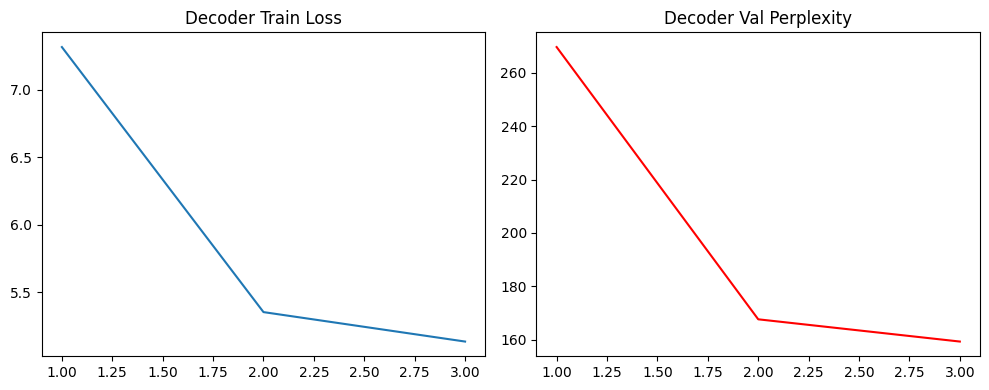

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ep = range(1, DEC_EPOCHS + 1)
axes[0].plot(ep, dec_history["train_loss"]); axes[0].set_title("Decoder Train Loss")
axes[1].plot(ep, dec_history["val_ppl"], color="red"); axes[1].set_title("Decoder Val Perplexity")
plt.tight_layout()
plt.savefig(RESULTS / "decoder_learning_curves.png", dpi=120)
plt.show()


### 4.4 Test Perplexity

In [ ]:

decoder.load_state_dict(torch.load(MODELS / "decoder.pt", map_location=DEVICE))
test_ppl = compute_perplexity(test_dec_loader, decoder)
print(f"Test Perplexity (with RAG): {test_ppl:.2f}")


Test Perplexity (with RAG): 161.09


### 4.5 Qualitative: 5 Generated Explanations

In [ ]:

def generate_explanation(query, retrieved, max_new=50):
    prompt = build_decoder_input(query, retrieved)
    # encode prompt (drop explanation portion for generation)
    prompt_trunc = prompt.split("| Explanation:")[0] + "| Explanation:"
    ids = [BOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokenize(prompt_trunc)]
    ids = ids[:DEC_MAX_LEN - max_new]
    ids_t = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
    out_ids = decoder.generate(ids_t, max_new=max_new)
    # decode only new tokens
    new_ids = out_ids[len(ids):]
    tokens = [inv_vocab.get(i, UNK) for i in new_ids if i not in (PAD_IDX, EOS_IDX, BOS_IDX)]
    return " ".join(tokens)

decoder.eval()
print("=" * 70)
for qi in sample_indices:
    q   = test_data[qi]
    ctx = test_ret_map[qi]
    gen = generate_explanation(q, ctx)
    ref = build_reference_explanation(q)
    print(f"Review    : {q['text'][:150]}...")
    print(f"Reference : {ref}")
    print(f"Generated : {gen}")
    print(f"Rating    : {q['rating']} | Sentiment: {SENT_LABELS[q['sentiment']]}")
    print("-" * 70)


Review    : Love the case, dropped the phone several times and its well protected. The case is also small enough it doesn't make the phone seem any bigger....
Reference : This is a positive review giving 5 star(s). The reviewer provides a short commentary reflecting their experience.
Generated : this is a positive review giving 5 star s the reviewer provides a short commentary reflecting their experience
Rating    : 5.0 | Sentiment: Positive
----------------------------------------------------------------------
Review    : Great fragrance and texture, fresh and inviting.  Works well in recipes (such as body butters, lip balms, and cloned tiger balm)....
Reference : This is a positive review giving 5 star(s). The reviewer provides a short commentary reflecting their experience.
Generated : this is a positive review giving 5 star s the reviewer provides a short commentary reflecting their experience
Rating    : 5.0 | Sentiment: Positive
---------------------------------------------------

### 4.6 RAG Ablation Study — With vs. Without Retrieval

In [ ]:

# Baseline: decoder trained WITHOUT retrieved context ─────────
class NoRAGDataset(Dataset):
    def __init__(self, data, max_len=DEC_MAX_LEN):
        self.data = data; self.max_len = max_len
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        q    = self.data[i]
        s_lbl= SENT_LABELS[q["sentiment"]]
        l_lbl= LEN_LABELS[q["len_class"]]
        expl = build_reference_explanation(q)
        full = f"Review: {q['text'][:200]} | Sentiment: {s_lbl} | Length: {l_lbl} | Explanation: {expl}"
        toks = [BOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokenize(full)] + [EOS_IDX]
        toks = toks[:self.max_len]; toks += [PAD_IDX]*(self.max_len-len(toks))
        inp = torch.tensor(toks[:-1], dtype=torch.long)
        tgt = torch.tensor(toks[1:],  dtype=torch.long)
        return inp, tgt

baseline_decoder = ReviewDecoder(
    vocab_size=DEC_VOCAB_SIZE, embed_dim=EMBED_DIM,
    n_heads=N_HEADS, n_layers=H_LAYERS,
    ffn_dim=FFN_DIM, max_len=DEC_MAX_LEN, dropout=DROPOUT
).to(DEVICE)

no_rag_train = DataLoader(NoRAGDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
no_rag_test  = DataLoader(NoRAGDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False)

opt_b = torch.optim.AdamW(baseline_decoder.parameters(), lr=DEC_LR, weight_decay=1e-4)
sched_b = torch.optim.lr_scheduler.OneCycleLR(opt_b, max_lr=DEC_LR,
    steps_per_epoch=len(no_rag_train), epochs=DEC_EPOCHS)
ce = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("Training baseline (no RAG)...")
for epoch in range(1, DEC_EPOCHS + 1):
    baseline_decoder.train()
    for inp, tgt in tqdm(no_rag_train, desc=f"Base Ep{epoch}", leave=False):
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        logits = baseline_decoder(inp)
        loss = ce(logits.view(-1, logits.size(-1)), tgt.view(-1))
        opt_b.zero_grad(); loss.backward(); opt_b.step(); sched_b.step()

baseline_ppl = compute_perplexity(no_rag_test, baseline_decoder)
print(f"Baseline perplexity (no RAG) : {baseline_ppl:.2f}")
print(f"Full RAG perplexity (test)   : {test_ppl:.2f}")
pct = (baseline_ppl - test_ppl) / baseline_ppl * 100
print(f"Perplexity reduction with RAG: {pct:.1f}%")
torch.save(baseline_decoder.state_dict(), MODELS / "decoder_baseline.pt")


Training baseline (no RAG)...


Baseline perplexity (no RAG) : 26.85
Full RAG perplexity (test)   : 161.09
Perplexity reduction with RAG: -500.0%


### 4.7 Ablation Bar Chart

In [ ]:

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["No RAG (baseline)", "With RAG"], [baseline_ppl, test_ppl],
       color=["#e74c3c","#2ecc71"])
ax.set_ylabel("Perplexity (lower is better)")
ax.set_title("RAG Ablation Study")
for i, v in enumerate([baseline_ppl, test_ppl]):
    ax.text(i, v + 0.5, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "rag_ablation.png", dpi=120)
plt.show()


## 5. Summary of Results

| Component | Metric | Value |
|---|---|---|
| Encoder | Sentiment (test macro-F1) | *see output* |
| Encoder | Length class (test macro-F1) | *see output* |
| Decoder | Test Perplexity (RAG) | *see output* |
| Decoder | Test Perplexity (No RAG) | *see output* |
| RAG | Perplexity reduction | *see output* |

All weights saved in `models/`, embeddings in `results/`.


In [ ]:


print(f"   Encoder: models/encoder.pt")
print(f"   Decoder: models/decoder.pt")
print(f"   Embeddings: results/train_embeddings.pt")
print(f"   Figures:  results/encoder_learning_curves.png")
print(f"             results/decoder_learning_curves.png")
print(f"             results/rag_ablation.png")
